In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv


In [2]:
!pip install transformers
!pip install tensorflow==2.1.0
!pip install simpletransformers
!pip install tokenizers==0.7.0

     |████████████████████████████████| 184 kB 2.4 MB/s 
     |████████████████████████████████| 635 kB 4.8 MB/s 
  Created wheel for seqeval: filename=seqeval-0.0.12-py3-none-any.whl size=7423 sha256=7855980f6b83def00db189995ab9190a3d2f3d6efc7373a2f136c32a1572b254
  Stored in directory: /root/.cache/pip/wheels/dc/cc/62/a3b81f92d35a80e39eb9b2a9d8b31abac54c02b21b2d466edc
Successfully built seqeval
ERROR: transformers 2.9.0 has requirement tokenizers==0.7.0, but you'll have tokenizers 0.5.2 which is incompatible.
  Attempting uninstall: transformers
    Found existing installation: transformers 2.8.0
    Uninstalling transformers-2.8.0:
      Successfully uninstalled transformers-2.8.0
     |████████████████████████████████| 5.6 MB 2.8 MB/s 
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.5.2
    Uninstalling tokenizers-0.5.2:
      Successfully uninstalled tokenizers-0.5.2


In [3]:
!export CUDA_HOME=/usr/local/cuda-10.1
!git clone https://github.com/NVIDIA/apex
%cd apex
!pip install -v --no-cache-dir ./

Cloning into 'apex'...
remote: Enumerating objects: 6742, done.
remote: Total 6742 (delta 0), reused 0 (delta 0), pack-reused 6742
Receiving objects: 100% (6742/6742), 13.73 MiB | 24.46 MiB/s, done.
Resolving deltas: 100% (4505/4505), done.
/kaggle/working/apex
Non-user install because site-packages writeable
Created temporary directory: /tmp/pip-ephem-wheel-cache-mzz0ctte
Created temporary directory: /tmp/pip-req-tracker-cf0y6_c2
Initialized build tracking at /tmp/pip-req-tracker-cf0y6_c2
Created build tracker: /tmp/pip-req-tracker-cf0y6_c2
Entered build tracker: /tmp/pip-req-tracker-cf0y6_c2
Created temporary directory: /tmp/pip-install-38la_ju5
Processing /kaggle/working/apex
  Created temporary directory: /tmp/pip-req-build-s_5am7fh
  Added file:///kaggle/working/apex to build tracker '/tmp/pip-req-tracker-cf0y6_c2'
    Running setup.py (path:/tmp/pip-req-build-s_5am7fh/setup.py) egg_info for package from file:///kaggle/working/apex
    Running command python setup.py egg_info
    

In [4]:
import logging

logging.basicConfig(level=logging.INFO)
transformers_logger = logging.getLogger("transformers")
transformers_logger.setLevel(logging.WARNING)

In [5]:
import pandas as pd

df = pd.read_csv("/kaggle/input/real-or-fake-fake-jobposting-prediction/fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


Check for Missing Values

In [6]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2695
benefits                7210
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

Check Real vs Fake class distribution

0    17014
1      866
Name: fraudulent, dtype: int64


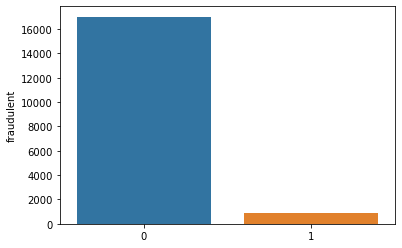

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
print(df["fraudulent"].value_counts())
sns.barplot(df["fraudulent"].unique(), df["fraudulent"].value_counts())

We see that the data is highly imbalanced in favor of the real class

In [8]:
df.fillna(' ',inplace=True)

We will concatenate all the textual data that could have an impact that we have

In [9]:
df['text'] = df['title'] + " " + df['department'] + \
             " " + df['company_profile'] + " " + \
             df['description'] + " " + \
             df['requirements'] + " " +\
             df['benefits'] + " " +\
             df['function'] + " " \

Then we delete all the unnecessary columns

In [10]:
delete_list=['job_id','title','location','telecommuting','has_company_logo','has_questions','department','salary_range','company_profile','description','requirements','benefits','employment_type','required_experience','required_education','industry','function']

for val in delete_list:
    del df[val]
df.head()

,fraudulent,text
0,0,"Marketing Intern Marketing We're Food52, and w..."
1,0,Customer Service - Cloud Video Production Succ...
2,0,Commissioning Machinery Assistant (CMA) Valo...
3,0,Account Executive - Washington DC Sales Our pa...
4,0,Bill Review Manager SpotSource Solutions LLC...


In [11]:
import spacy, re
#Data Cleanup

df['text']=df['text'].str.replace('\n','')
df['text']=df['text'].str.replace('\r','')
df['text']=df['text'].str.replace('\t','')
  
#This removes unwanted texts
df['text'] = df['text'].apply(lambda x: re.sub(r'[0-9]','',x))
df['text'] = df['text'].apply(lambda x: re.sub(r'[/(){}\[\]\|@,;.:-]',' ',x))
  
#Converting all upper case to lower case
df['text']= df['text'].apply(lambda s:s.lower() if type(s) == str else s)
  

#Remove un necessary white space
df['text']=df['text'].str.replace('  ',' ')

#Remove Stop words
nlp=spacy.load("en_core_web_sm")
df['text'] =df['text'].apply(lambda x: ' '.join([word for word in x.split() if nlp.vocab[word].is_stop==False ]))

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df.fraudulent, test_size = 0.20, stratify=df.fraudulent, random_state=777)

train_df = pd.DataFrame({0: X_train, 1: y_train})
test_df = pd.DataFrame({0: X_test, 1: y_test})

In [13]:
from simpletransformers.classification import ClassificationModel


model = ClassificationModel('bert', 'bert-base-uncased', num_labels=2, args={'overwrite_output_dir': True, "train_batch_size": 64, "save_steps": 10000, "save_model_every_epoch":False,
                                                                           'num_train_epochs': 4}, use_cuda=True)

In [14]:
model.train_model(train_df)

/opt/conda/lib/python3.7/site-packages/simpletransformers/classification/classification_model.py:251: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  "Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels."



Selected optimization level O1:  Insert automatic casts around Pytorch functions and Tensor methods.

Defaults for this optimization level are:
enabled                : True
opt_level              : O1
cast_model_type        : None
patch_torch_functions  : True
keep_batchnorm_fp32    : None
master_weights         : None
loss_scale             : dynamic
Processing user overrides (additional kwargs that are not None)...
After processing overrides, optimization options are:
enabled                : True
opt_level              : O1
cast_model_type        : None
patch_torch_functions  : True
keep_batchnorm_fp32    : None
master_weights         : None
loss_scale             : dynamic


Running loss: 0.833762

/opt/conda/lib/python3.7/site-packages/torch/optim/lr_scheduler.py:113: UserWarning: Seems like `optimizer.step()` has been overridden after learning rate scheduler initialization. Please, make sure to call `optimizer.step()` before `lr_scheduler.step()`. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  "https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate", UserWarning)


Running loss: 0.269625

/opt/conda/lib/python3.7/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  warnings.warn("To get the last learning rate computed by the scheduler, "


Running loss: 0.190300Gradient overflow.  Skipping step, loss scaler 0 reducing loss scale to 32768.0
Running loss: 0.061969


Running loss: 0.341323


Running loss: 0.007482


Running loss: 0.000974



In [15]:
# Evaluate the model
result, model_outputs, wrong_predictions = model.eval_model(test_df)

/opt/conda/lib/python3.7/site-packages/simpletransformers/classification/classification_model.py:668: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  "Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels."


In [16]:
import numpy as np
preds = [np.argmax(tuple(m)) for m in model_outputs]

In [17]:
from sklearn.metrics import f1_score

print(f1_score(test_df[1], preds, average='micro'))
print(f1_score(test_df[1], preds, average='macro'))

0.985738255033557
0.9187550422827848


In [18]:
from sklearn.metrics import classification_report

print(classification_report(test_df[1], preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.89      0.80      0.84       173

    accuracy                           0.99      3576
   macro avg       0.94      0.90      0.92      3576
weighted avg       0.99      0.99      0.99      3576

